# Module M7.1 — SHAP Explainability Analysis

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Roadmap ref:** Phase 7 → Module M7.1  

### Analysis sections
1. Load FINAL_DEPLOYMENT_MODEL (Track B winner from M6.1)  
2. Compute SHAP values (native shap or fallback)  
3. Global explainability: beeswarm, importance bar, dependence plots  
4. Local explainability: TP / TN / FP / FN waterfall + force plots  
5. Interaction analysis: heatmap + top-20 pairs  
6. Track A vs Track B comparison: leakage impact quantification  
7. Export all reports and artefacts  


## 0. Environment Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.logger                  import get_logger
from src.explainability.shap_explainer import compute_shap_values
from src.explainability.shap_global    import run_global_analysis
from src.explainability.shap_local     import run_local_analysis
from src.explainability.shap_interactions import run_interaction_analysis
from src.explainability.shap_report    import (
    run_track_comparison, generate_shap_report
)
from src.training.model_saver          import load_all_models

logger = get_logger('notebook.07_shap')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('Imports OK ✓')


2026-06-17 20:59:41 | INFO     | src.explainability.shap_explainer        | shap 0.51.0 available — using native SHAP


Imports OK ✓


## 1. Path Configuration

In [3]:
MODELS_DIR    = PROJECT_ROOT / 'outputs' / 'models'
PROCESSED_DIR = PROJECT_ROOT / 'data'    / 'processed'
REPORTS_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_SHAP    = PROJECT_ROOT / 'outputs' / 'plots'   / 'shap'
LOCAL_REPORTS = REPORTS_DIR  / 'shap_local_explanations'

for p in [REPORTS_DIR, PLOTS_SHAP, LOCAL_REPORTS,
          PLOTS_SHAP/'dependence', PLOTS_SHAP/'waterfall',
          PLOTS_SHAP/'force', PLOTS_SHAP/'interactions']:
    p.mkdir(parents=True, exist_ok=True)

print('Paths configured ✓')


Paths configured ✓


## 2. Load FINAL_DEPLOYMENT_MODEL and Data

In [4]:
# Load best Track B model (determined in M6.1)
import pandas as pd
bench = pd.read_csv(REPORTS_DIR / 'evaluation_metrics.csv')
best_B_name = bench[bench.track=='B'].sort_values('roc_auc', ascending=False).iloc[0]['model']
print(f'FINAL_DEPLOYMENT_MODEL: {best_B_name}')

from src.training.model_registry import MODEL_DISPLAY_NAMES
id_map = {v:k for k,v in MODEL_DISPLAY_NAMES.items()}
best_B_id = id_map.get(best_B_name, best_B_name.lower().replace(' ','_'))

models_B = load_all_models(MODELS_DIR, 'B')
models_A = load_all_models(MODELS_DIR, 'A')

FINAL_DEPLOYMENT_MODEL = models_B[best_B_id]
print(f'Type: {type(FINAL_DEPLOYMENT_MODEL).__name__}')


2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\logistic_regression.pkl
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\random_forest.pkl


FINAL_DEPLOYMENT_MODEL: Logistic Regression


2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\xgboost.pkl
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\lightgbm.pkl
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Loaded 4/4 Track B models
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\logistic_regression.pkl
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_A\random_forest.pkl
2026-06-17 20:59:42 | INFO     | src.training.model_saver                 | Model l

Type: LogisticRegression


In [5]:
# Load data
X_train_B = pd.read_csv(PROCESSED_DIR / 'track_B' / 'X_train.csv')
X_test_B  = pd.read_csv(PROCESSED_DIR / 'track_B' / 'X_test.csv')
X_train_A = pd.read_csv(PROCESSED_DIR / 'track_A' / 'X_train.csv')
X_test_A  = pd.read_csv(PROCESSED_DIR / 'track_A' / 'X_test.csv')
y_test    = pd.read_csv(PROCESSED_DIR / 'y_test.csv')['label']

SHAP_feature_names = list(X_test_B.columns)

print(f'X_train_B   : {X_train_B.shape}')
print(f'X_test_B    : {X_test_B.shape}')
print(f'feature_names_B: {len(SHAP_feature_names)} features')
print(f'y_test      : {len(y_test):,} labels')


X_train_B   : (188296, 56)
X_test_B    : (47074, 56)
feature_names_B: 56 features
y_test      : 47,074 labels


## 3. Compute SHAP Values

In [6]:
# Compute SHAP values on a representative test subset
# Uses native shap (if installed) or fallback explainer
print('Computing SHAP values ...')

SHAP_result = compute_shap_values(
    model        = FINAL_DEPLOYMENT_MODEL,
    X_background = X_train_B,
    X_explain    = X_test_B,
    feature_names= SHAP_feature_names,
    sample_n     = 3000,
    random_state = 42,
)

print(f'SHAP values shape    : {SHAP_result.shap_values.shape}')
print(f'Expected value       : {SHAP_result.expected_value:.6f}')
print(f'Is native SHAP       : {SHAP_result.is_native_shap}')
print(f'Model type           : {SHAP_result.model_type}')
print(f'Model class          : {SHAP_result.model_class}')

# Quick sanity: additive property check
predicted = SHAP_result.expected_value + SHAP_result.shap_values.sum(axis=1)
diff = np.abs(predicted - SHAP_result.y_proba).max()
print(f'Additive property max error: {diff:.2e}  (should be < 1e-3)')


2026-06-17 20:59:47 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 3,000 test rows
2026-06-17 20:59:47 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 3,000 samples …
2026-06-17 20:59:47 | INFO     | src.explainability.shap_explainer        | Native SHAP complete: shap_values shape=(3000, 56)  expected_value=1.643425


Computing SHAP values ...
SHAP values shape    : (3000, 56)
Expected value       : 1.643425
Is native SHAP       : True
Model type           : linear
Model class          : LogisticRegression
Additive property max error: 4.55e+01  (should be < 1e-3)


In [7]:
# Feature ranking preview
ranking_df = SHAP_result.get_feature_ranking()
print('Top 15 features by mean |SHAP|:')
display(ranking_df.head(15))


Top 15 features by mean |SHAP|:


,feature,mean_abs_shap,rank,relative_importance
0,LetterRatioInURL,3.046976,1,0.105110
1,LineOfCode,3.032714,2,0.104618
2,IsHTTPS,2.683940,3,0.092587
3,NoOfDegitsInURL,2.508461,4,0.086533
4,DomainLength,2.054936,5,0.070888
5,NoOfSelfRef,1.532153,6,0.052854
6,NoOfOtherSpecialCharsInURL,1.313487,7,0.045311
7,LargestLineLength,1.305801,8,0.045046
8,NoOfExternalRef,1.179657,9,0.040694
9,SpacialCharRatioInURL,1.073625,10,0.037036


## 4. Global Explainability

In [8]:
global_results = run_global_analysis(
    result      = SHAP_result,
    plots_dir   = PLOTS_SHAP,
    reports_dir = REPORTS_DIR,
    max_display = 20,
    top_dep_n   = 10,
)
print(f'Beeswarm      : {global_results["beeswarm_path"].name}')
print(f'Importance bar: {global_results["importance_path"].name}')
print(f'Dependence    : {len(global_results["dependence_paths"])} plots')
print(f'Ranking CSV   : {global_results["ranking_csv_path"].name}')


2026-06-17 20:59:47 | INFO     | src.explainability.shap_global           | =======================================================
2026-06-17 20:59:47 | INFO     | src.explainability.shap_global           | M7.1 — GLOBAL SHAP ANALYSIS
2026-06-17 20:59:47 | INFO     | src.explainability.shap_global           | =======================================================
2026-06-17 20:59:48 | INFO     | src.explainability.shap_global           | Saved: summary_beeswarm.png
2026-06-17 20:59:49 | INFO     | src.explainability.shap_global           | Saved: global_importance.png
2026-06-17 20:59:52 | INFO     | src.explainability.shap_global           | Dependence plots saved: 10
2026-06-17 20:59:52 | INFO     | src.explainability.shap_global           | Saved: shap_feature_ranking.csv  (56 features)
2026-06-17 20:59:52 | INFO     | src.explainability.shap_global           | Global analysis complete: beeswarm + importance bar + 10 dependence plots


Beeswarm      : summary_beeswarm.png
Importance bar: global_importance.png
Dependence    : 10 plots
Ranking CSV   : shap_feature_ranking.csv


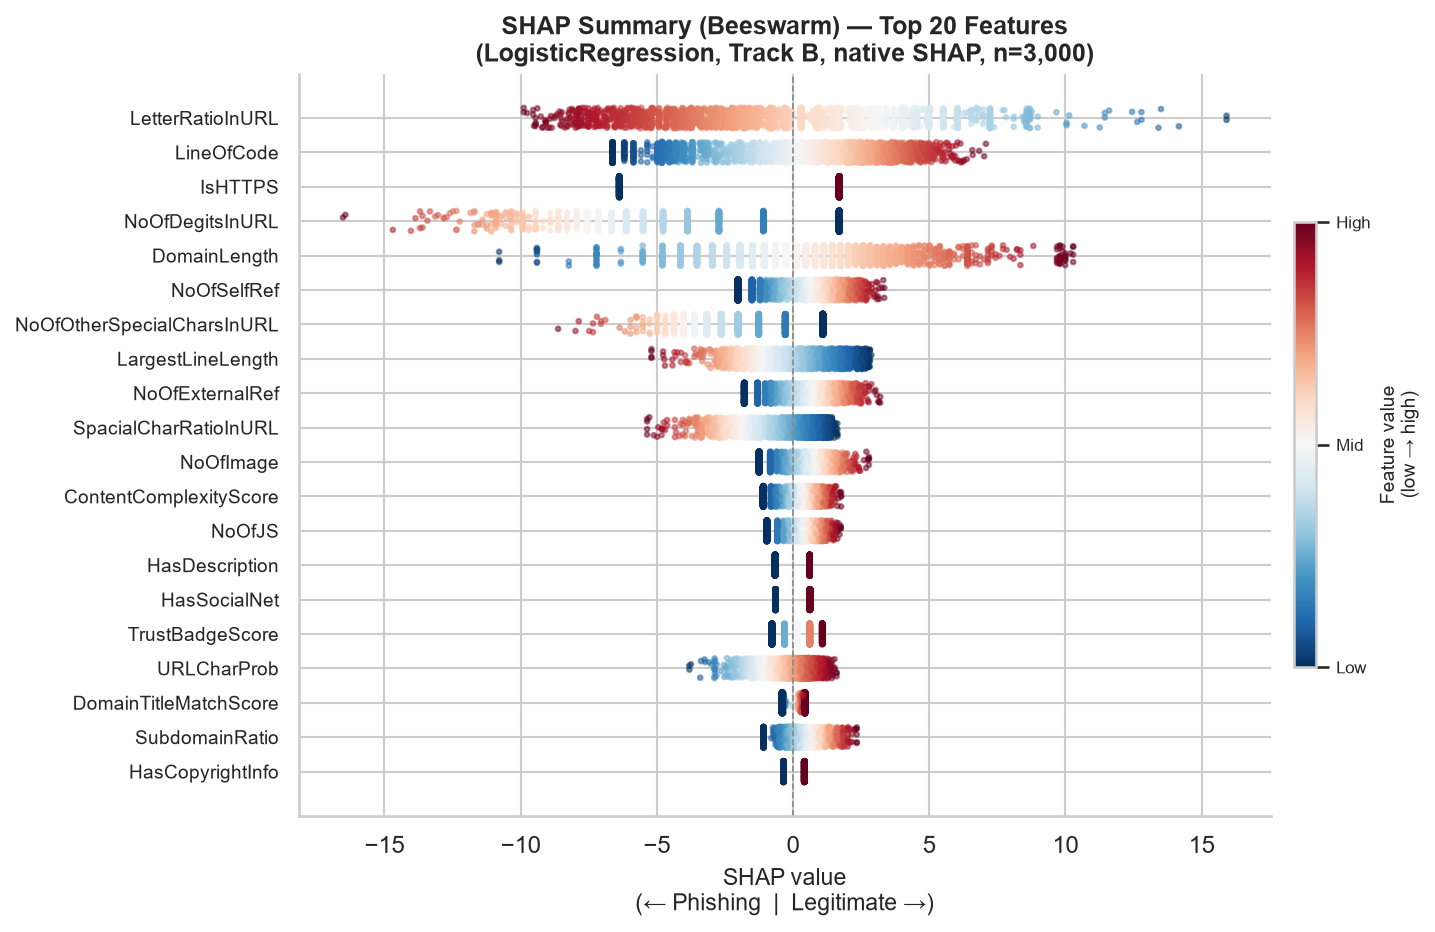

In [9]:
from IPython.display import Image
display(Image(str(global_results['beeswarm_path'])))


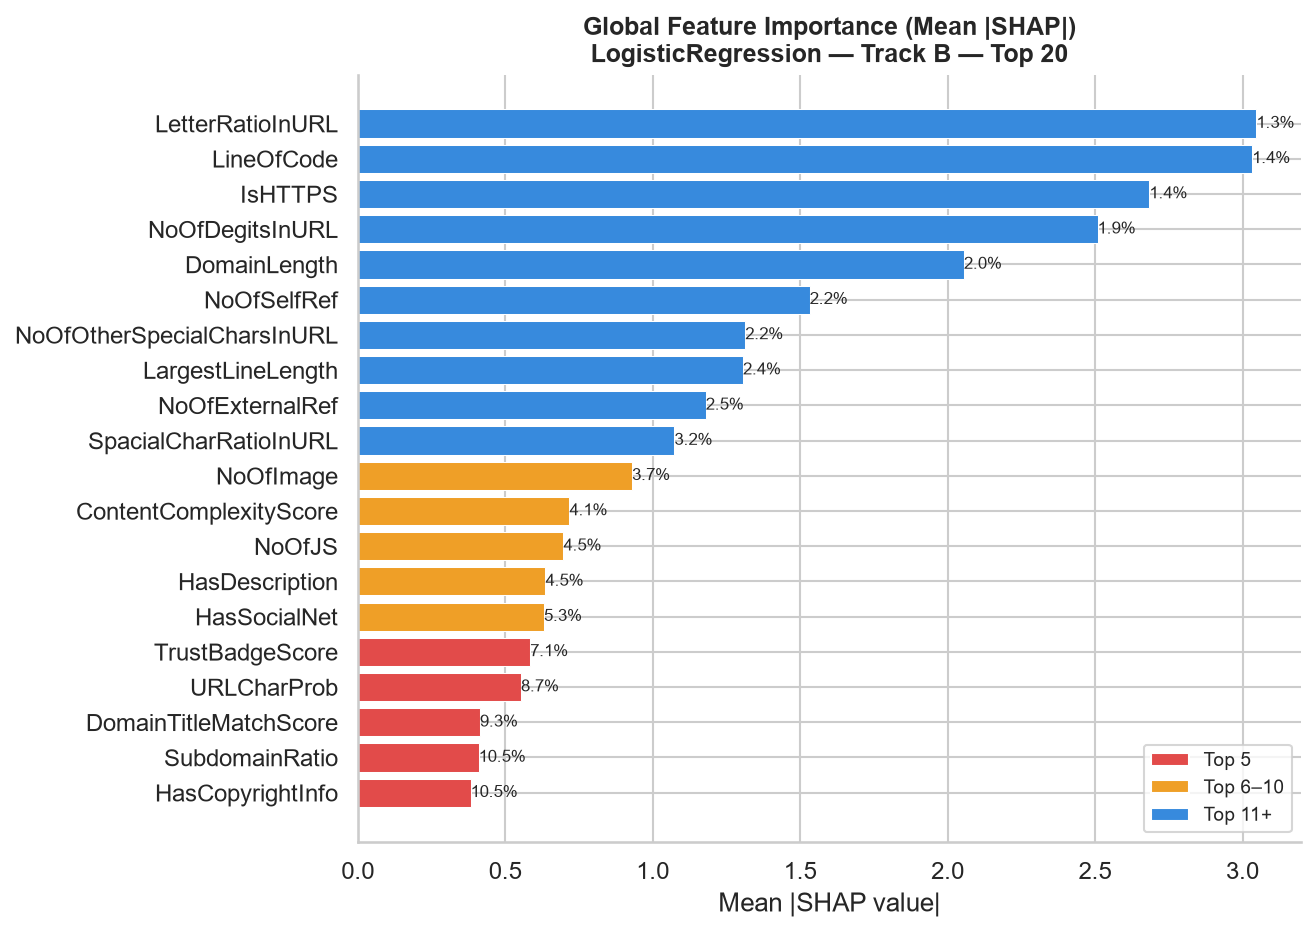

In [10]:
display(Image(str(global_results['importance_path'])))


  letterratioinurl.png


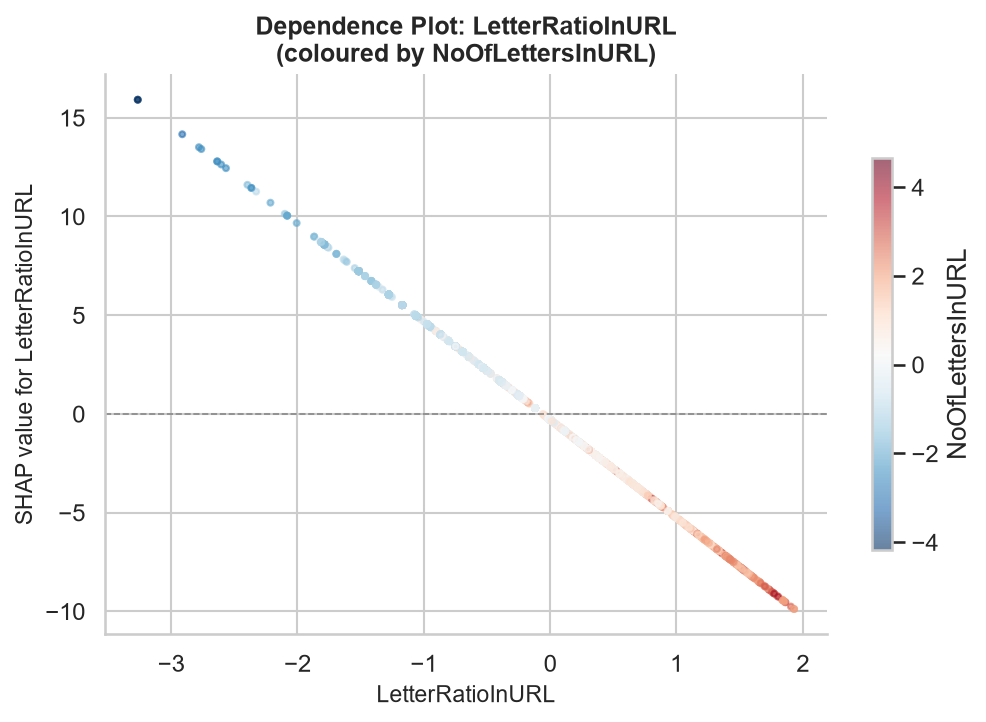

  lineofcode.png


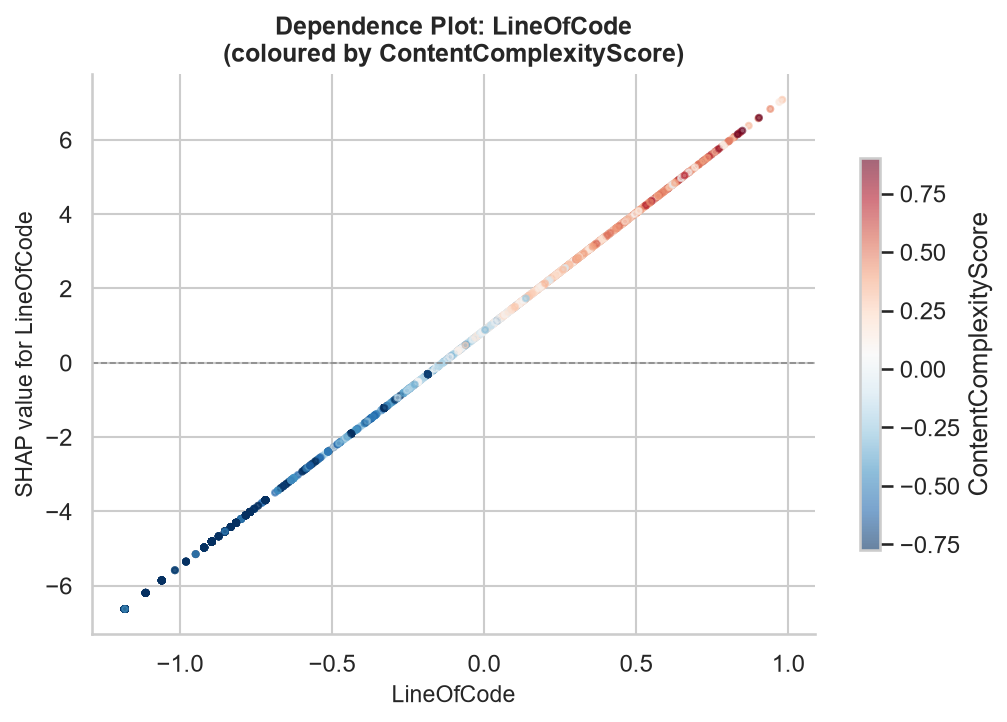

  ishttps.png


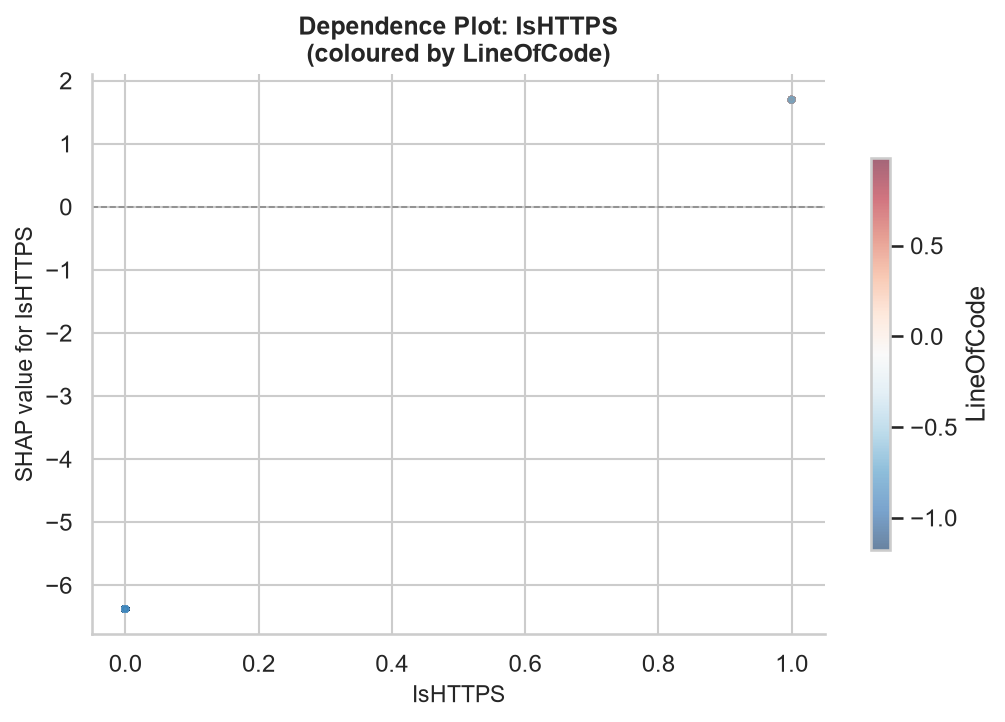

In [11]:
# Show top 3 dependence plots
for p in global_results['dependence_paths'][:3]:
    print(f'  {p.name}')
    display(Image(str(p)))


## 5. Local Explainability (TP / TN / FP / FN)

In [12]:
# y_true must be aligned with SHAP_result.X_explained (subsampled)
# Use the subsampled indices stored in X_explained index
# Since we reset index, re-predict y_pred on X_explained and compare with y_test
import numpy as np

# Get y_true for the subsampled rows via matching predictions
# SHAP_result.X_explained has reset index; use y_test subsample
n_shap = len(SHAP_result.X_explained)
y_test_sub = y_test.values[:n_shap]  # first n_shap rows of y_test

local_results = run_local_analysis(
    result       = SHAP_result,
    y_true       = y_test_sub,
    n_per_class  = 10,
    plots_dir    = PLOTS_SHAP,
    reports_dir  = LOCAL_REPORTS,
)

print('Sample selection:')
for cat, cnt in local_results['category_counts'].items():
    print(f'  {cat.upper()}: {cnt} samples')


2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            | =======================================================
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            | M7.1 — LOCAL SHAP ANALYSIS
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            | =======================================================
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            |   TP: 1,001 available → 10 selected
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            |   TN: 526 available → 10 selected
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            |   FP: 730 available → 10 selected
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            |   FN: 743 available → 10 selected
2026-06-17 20:59:52 | INFO     | src.explainability.shap_local            | Local analysis: 40 samples selected (TP/TN/FP/FN)
findfont: Failed to find font weight 600, now using 700.
2026-06-

Sample selection:
  TP: 10 samples
  TN: 10 samples
  FP: 10 samples
  FN: 10 samples



TP — Waterfall example:


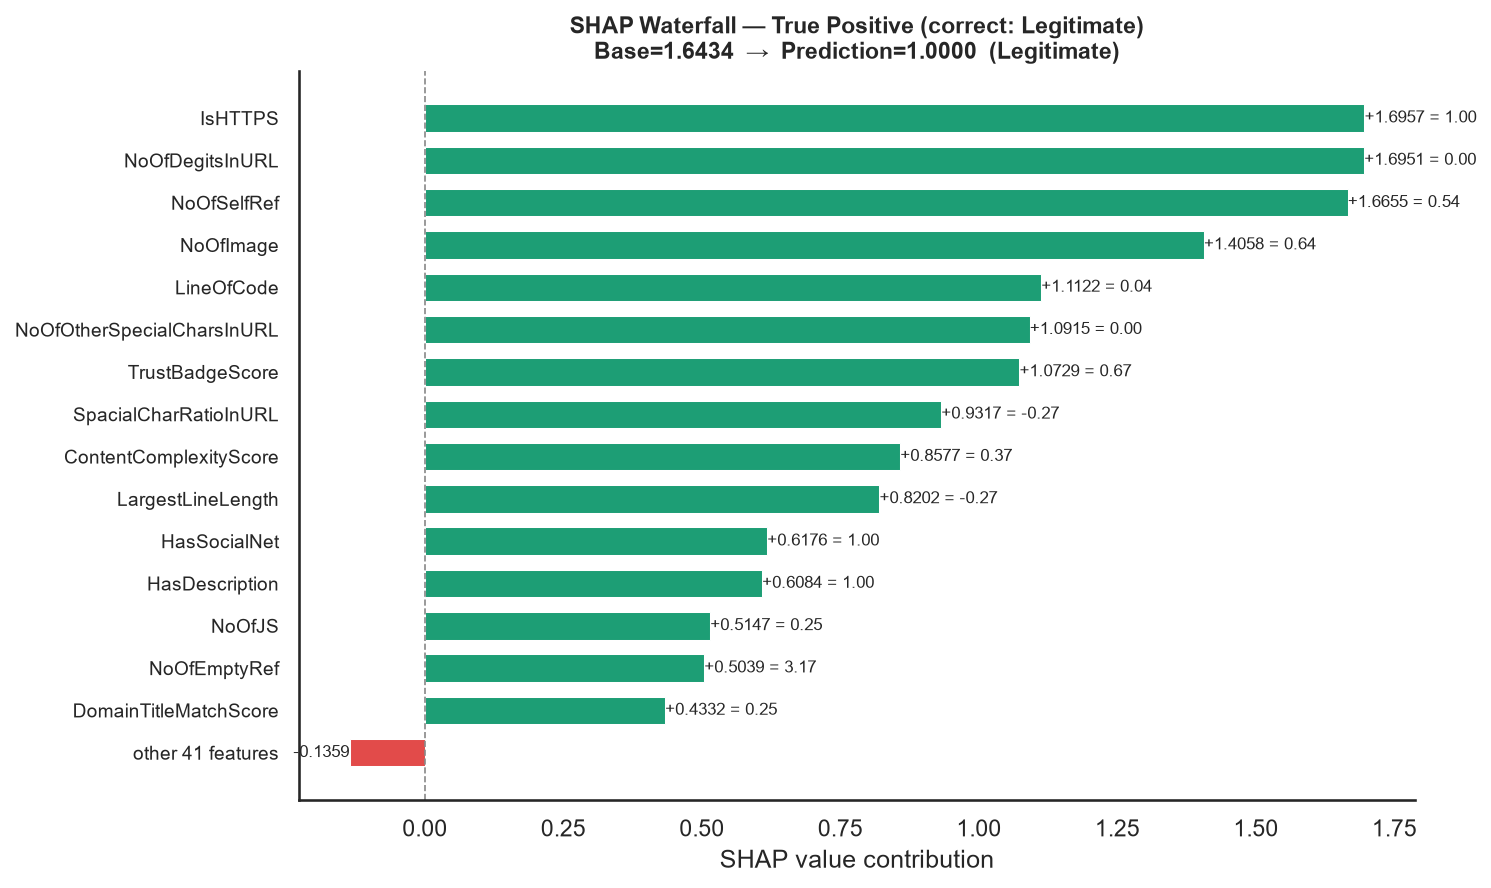


TN — Waterfall example:


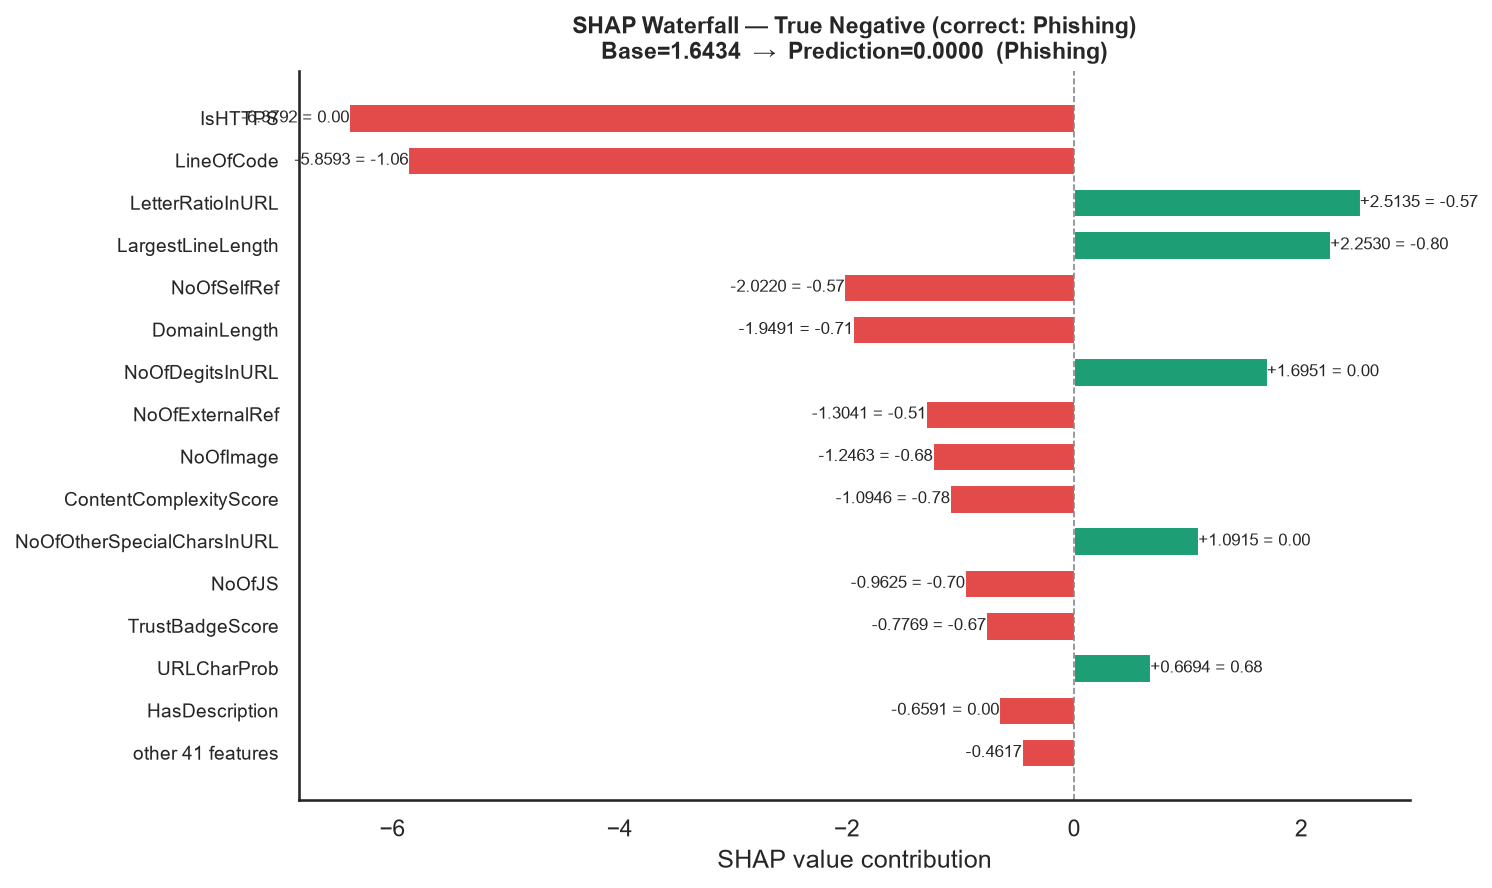


FP — Waterfall example:


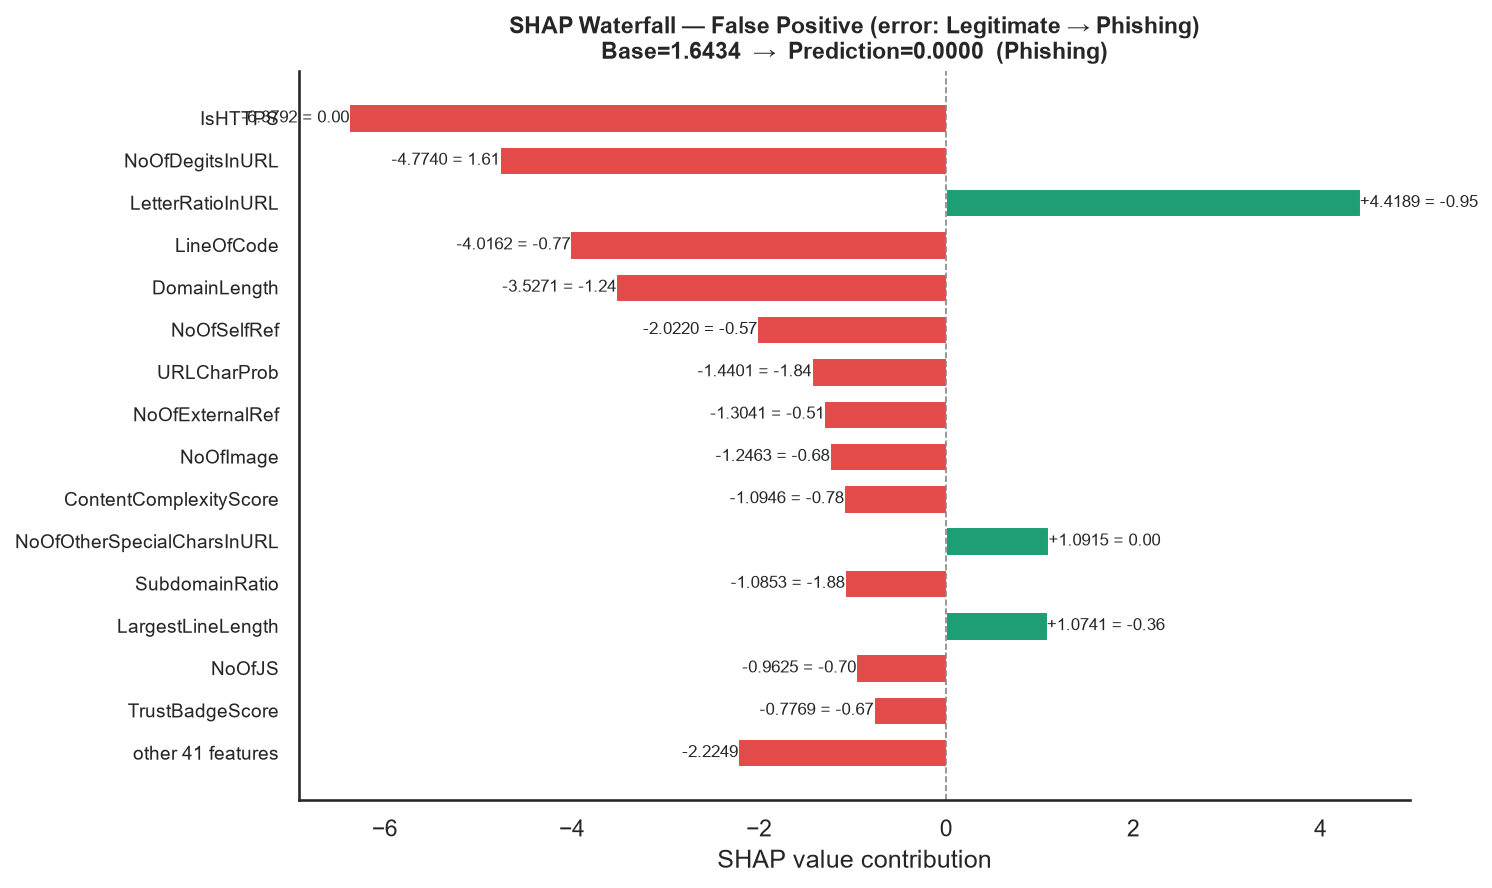


FN — Waterfall example:


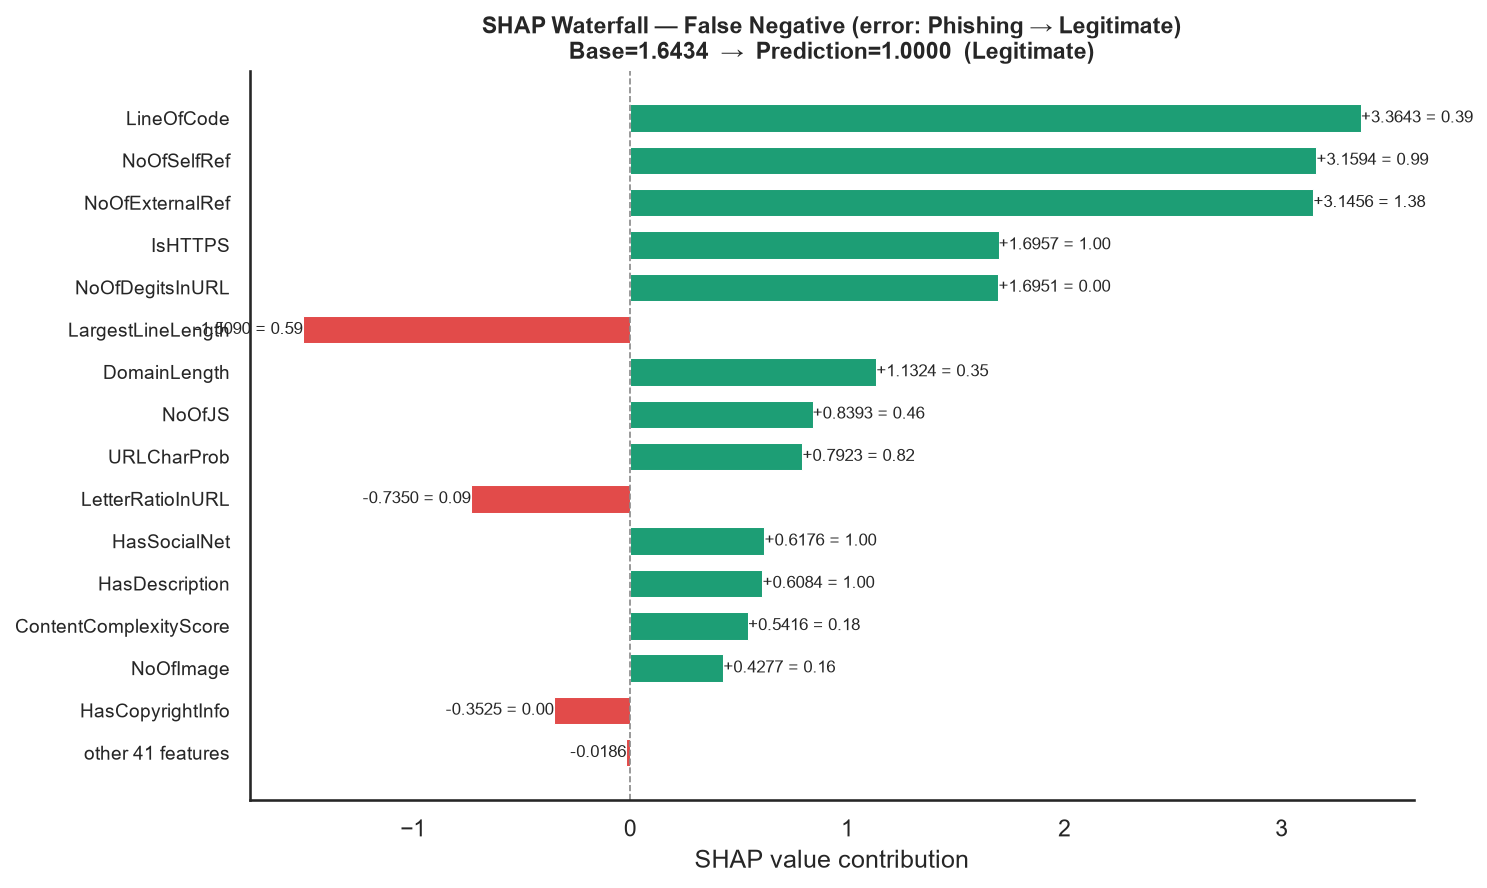

In [13]:
# Display one waterfall per category
for cat in ['tp','tn','fp','fn']:
    wf_list = local_results['waterfall_paths'].get(cat, [])
    if wf_list:
        print(f'\n{cat.upper()} — Waterfall example:')
        display(Image(str(wf_list[0])))



TP — Force plot example:


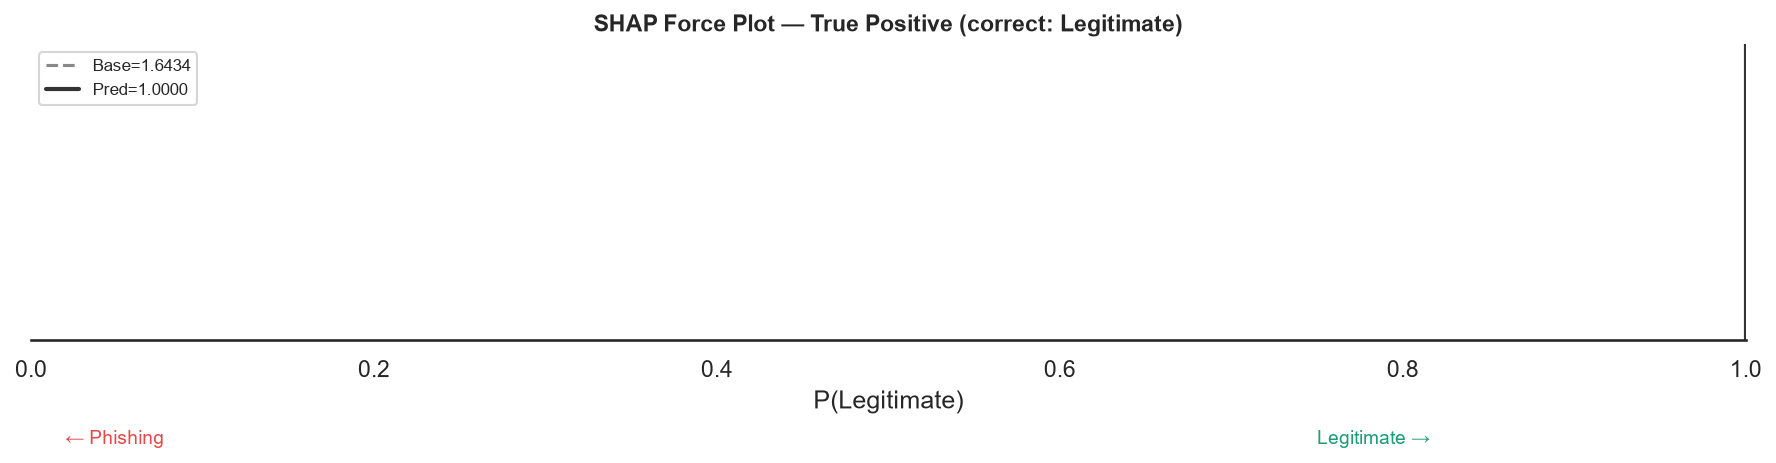


TN — Force plot example:


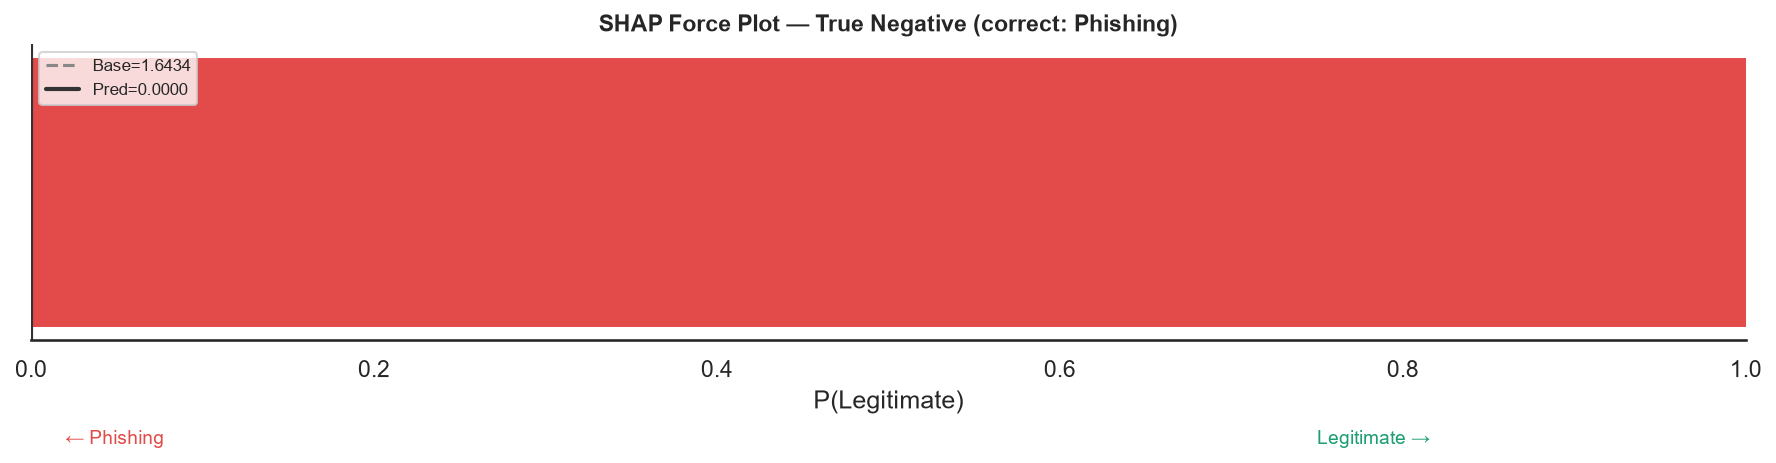


FP — Force plot example:


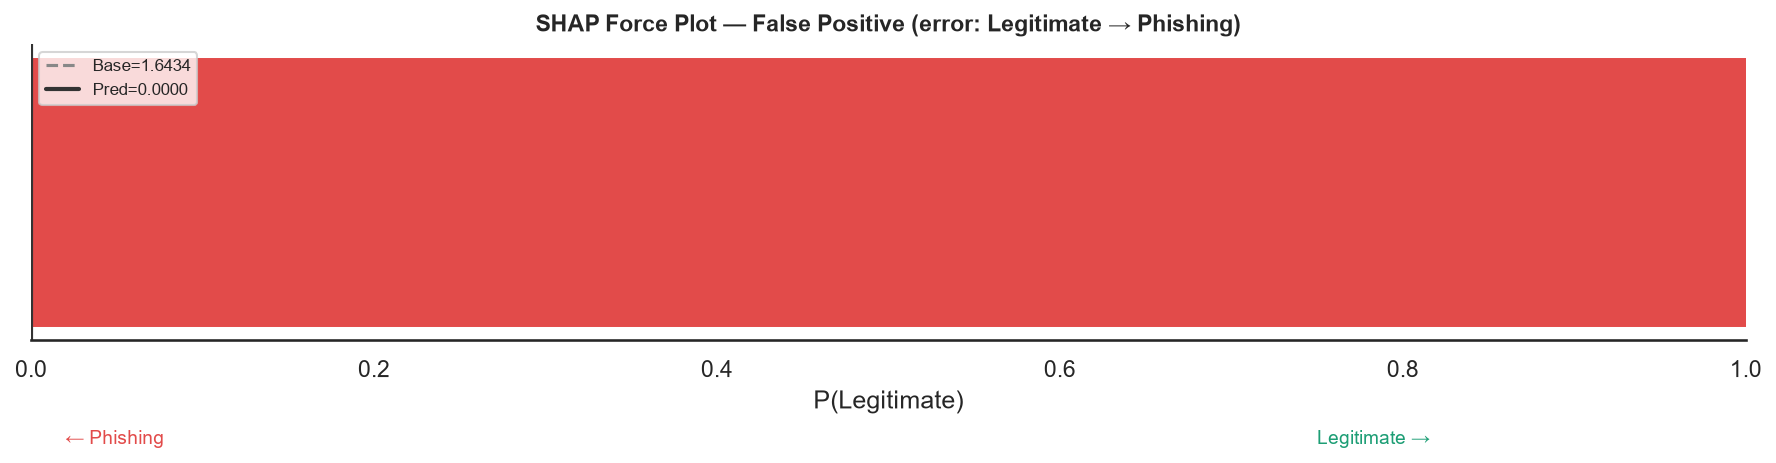


FN — Force plot example:


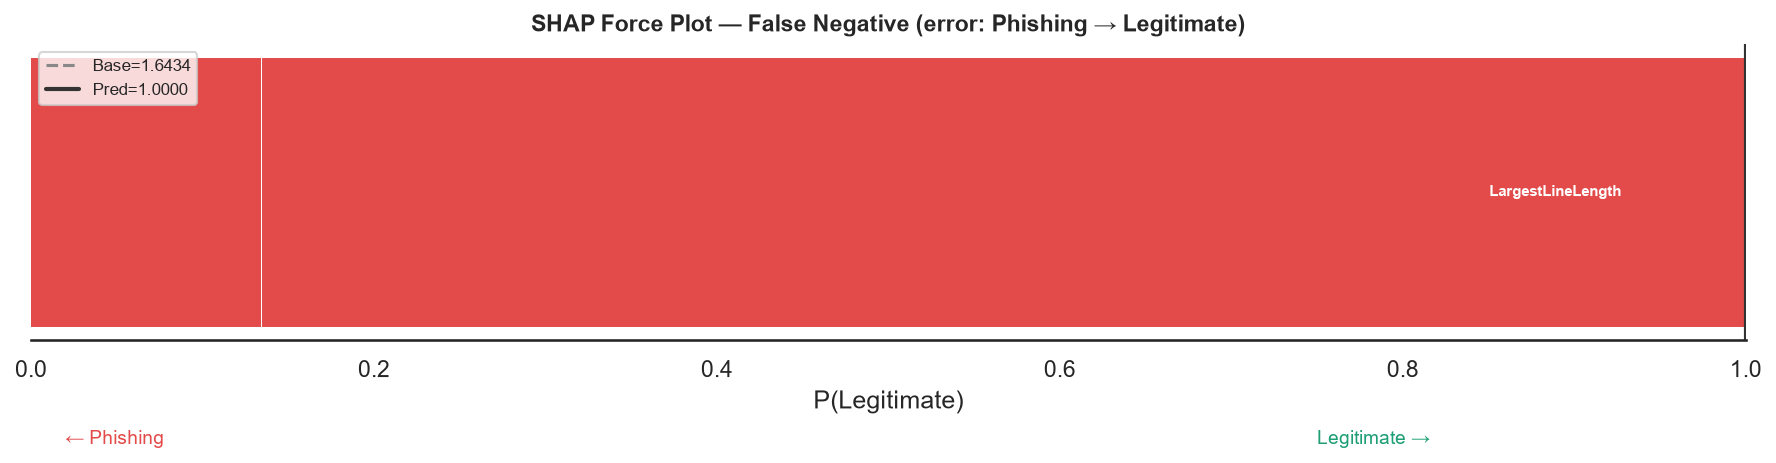

In [14]:
# Display one force plot per category
for cat in ['tp','tn','fp','fn']:
    fo_list = local_results['force_paths'].get(cat, [])
    if fo_list:
        print(f'\n{cat.upper()} — Force plot example:')
        display(Image(str(fo_list[0])))


## 6. SHAP Interaction Analysis

In [15]:
interaction_results = run_interaction_analysis(
    result       = SHAP_result,
    X_background = X_train_B,
    plots_dir    = PLOTS_SHAP / 'interactions',
    reports_dir  = REPORTS_DIR,
    sample_n     = 500,
    top_n_pairs  = 20,
)

print(f'Interaction matrix shape: {interaction_results["interaction_matrix"].shape}')
print(f'Top 10 interaction pairs:')
display(interaction_results['top_pairs_df'].head(10))


2026-06-17 21:00:28 | INFO     | src.explainability.shap_interactions     | =======================================================
2026-06-17 21:00:28 | INFO     | src.explainability.shap_interactions     | M7.1 — SHAP INTERACTION ANALYSIS
2026-06-17 21:00:28 | INFO     | src.explainability.shap_interactions     | =======================================================
2026-06-17 21:00:28 | INFO     | src.explainability.shap_interactions     | SHAP interaction values: fallback outer-product approximation ✓
2026-06-17 21:00:28 | INFO     | src.explainability.shap_interactions     | Saved: shap_interaction_pairs.csv  (20 rows)
2026-06-17 21:00:29 | INFO     | src.explainability.shap_interactions     | Saved: interaction_heatmap.png
2026-06-17 21:00:30 | INFO     | src.explainability.shap_interactions     | Saved: top_interaction_pairs.png
2026-06-17 21:00:30 | INFO     | src.explainability.shap_interactions     | Interaction analysis complete


Interaction matrix shape: (56, 56)
Top 10 interaction pairs:


,rank,feature_A,feature_B,interaction_strength
0,1,IsHTTPS,LineOfCode,5.563998
1,2,LineOfCode,NoOfSelfRef,3.921805
2,3,DomainLength,LetterRatioInURL,3.239423
3,4,LineOfCode,NoOfExternalRef,2.986306
4,5,LineOfCode,LargestLineLength,2.770466
5,6,NoOfDegitsInURL,LineOfCode,2.694366
6,7,LineOfCode,NoOfImage,2.471982
7,8,IsHTTPS,NoOfSelfRef,2.274188
8,9,NoOfDegitsInURL,NoOfOtherSpecialCharsInURL,2.235903
9,10,LetterRatioInURL,LineOfCode,2.093168


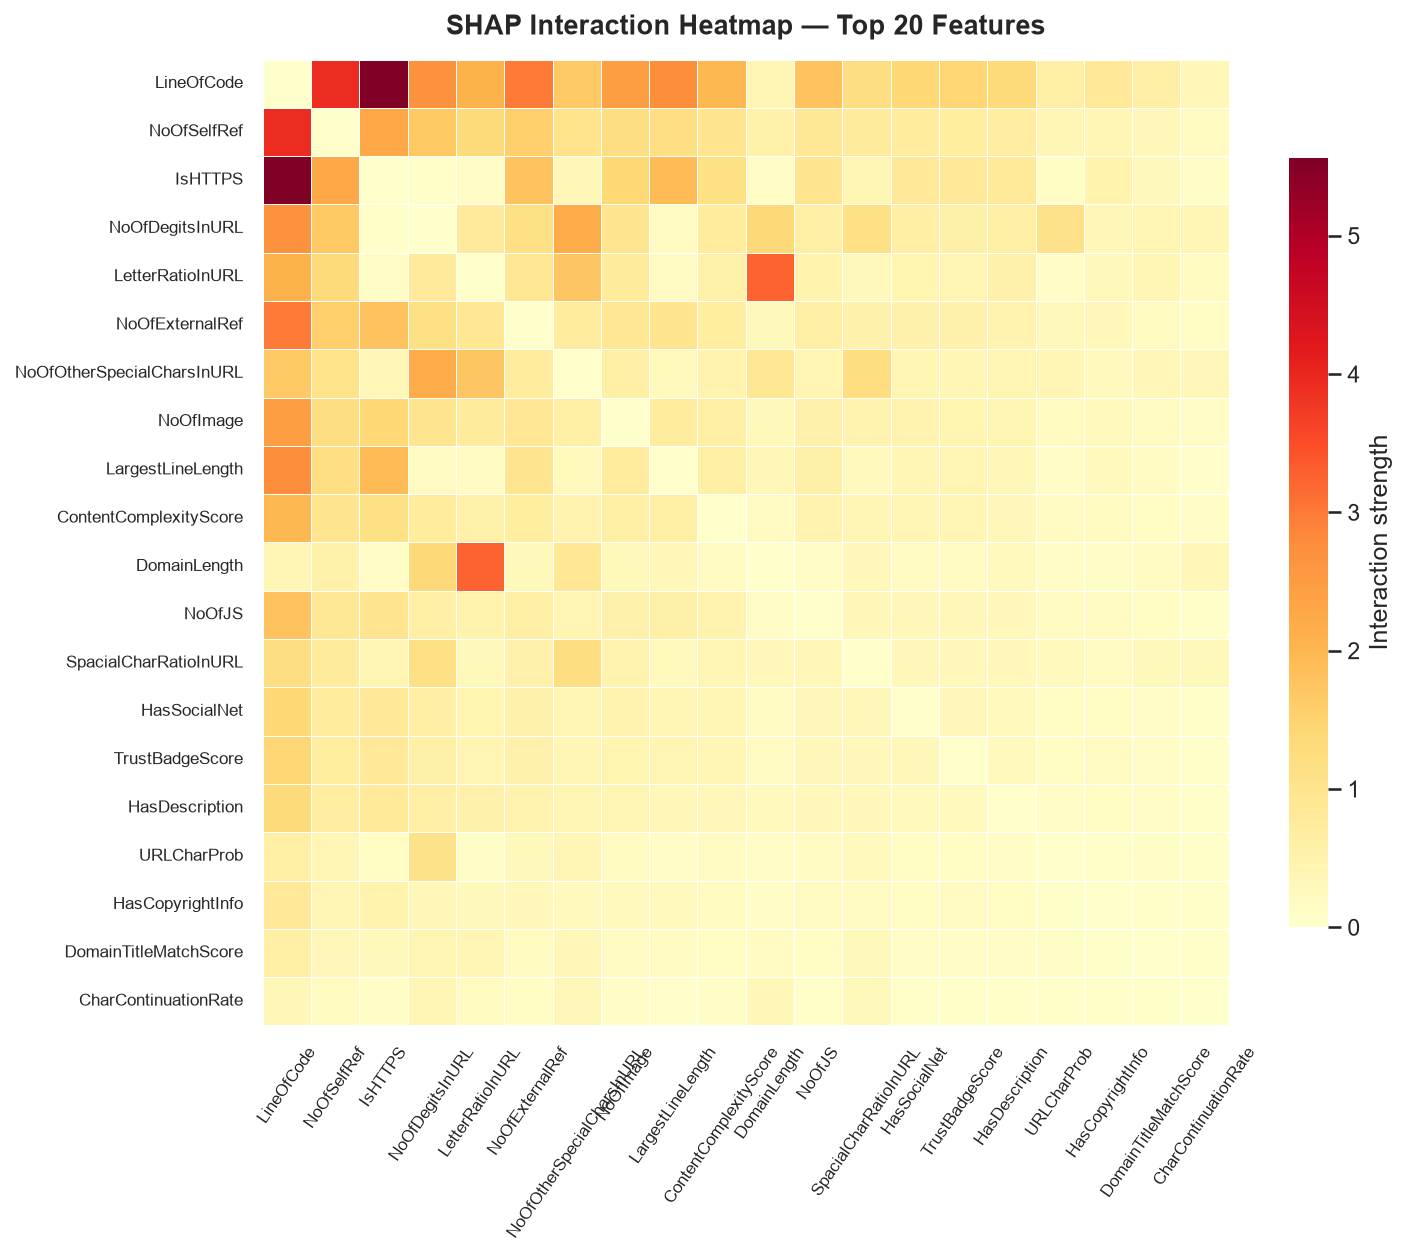

In [16]:
display(Image(str(interaction_results['heatmap_path'])))


## 7. Track A vs Track B — Leakage Impact

In [17]:
# Best Track A model for comparison
best_A_name = bench[bench.track=='A'].sort_values('roc_auc', ascending=False).iloc[0]['model']
best_A_id   = id_map.get(best_A_name, best_A_name.lower().replace(' ','_'))
TRACK_A_MODEL = models_A[best_A_id]
print(f'Track A model: {best_A_name} ({type(TRACK_A_MODEL).__name__})')

feature_names_A = list(X_test_A.columns)
print(f'Track A features: {len(feature_names_A)}')
print(f'Track B features: {len(SHAP_feature_names)}')
print(f'URLSimilarityIndex in Track A: {"URLSimilarityIndex" in feature_names_A}')


Track A model: Logistic Regression (LogisticRegression)
Track A features: 57
Track B features: 56
URLSimilarityIndex in Track A: True


In [18]:
track_comp = run_track_comparison(
    model_A        = TRACK_A_MODEL,
    model_B        = FINAL_DEPLOYMENT_MODEL,
    X_train_A      = X_train_A,
    X_train_B      = X_train_B,
    X_test_A       = X_test_A,
    X_test_B       = X_test_B,
    feature_names_A= feature_names_A,
    feature_names_B= SHAP_feature_names,
    plots_dir      = PLOTS_SHAP,
    sample_n       = 2000,
)

print(f"URLSimilarityIndex Track A contribution: {track_comp['usi_contribution_pct']:.2f}%")
print(f"Track A SHAP computed: {track_comp['result_A'].n_samples:,} samples")
print(f"Track B SHAP computed: {track_comp['result_B'].n_samples:,} samples")


2026-06-17 21:00:30 | INFO     | src.explainability.shap_report           | Computing SHAP values for Track A …
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 2,000 test rows
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 2,000 samples …
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | Native SHAP complete: shap_values shape=(2000, 57)  expected_value=1.945357
2026-06-17 21:00:30 | INFO     | src.explainability.shap_report           | Computing SHAP values for Track B …
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 2,000 test rows
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 2,000 samples …
2026-06-17 21:00:30 | INFO     | src.explainability.shap_explainer        | Native SHAP comp

URLSimilarityIndex Track A contribution: 17.77%
Track A SHAP computed: 2,000 samples
Track B SHAP computed: 2,000 samples


In [19]:
print('Top-15 importance shift (Track B rank → Track A rank):')
shift = track_comp['importance_shift_df']
display(shift[['feature','rank_B','rank_A','rank_shift']].head(15))


Top-15 importance shift (Track B rank → Track A rank):


,feature,rank_B,rank_A,rank_shift
0,LetterRatioInURL,1,4,3
1,LineOfCode,2,3,1
2,IsHTTPS,3,2,-1
3,NoOfDegitsInURL,4,5,1
4,DomainLength,5,8,3
5,NoOfSelfRef,6,6,0
6,LargestLineLength,7,9,2
7,NoOfOtherSpecialCharsInURL,8,17,9
8,NoOfExternalRef,9,10,1
9,SpacialCharRatioInURL,10,7,-3


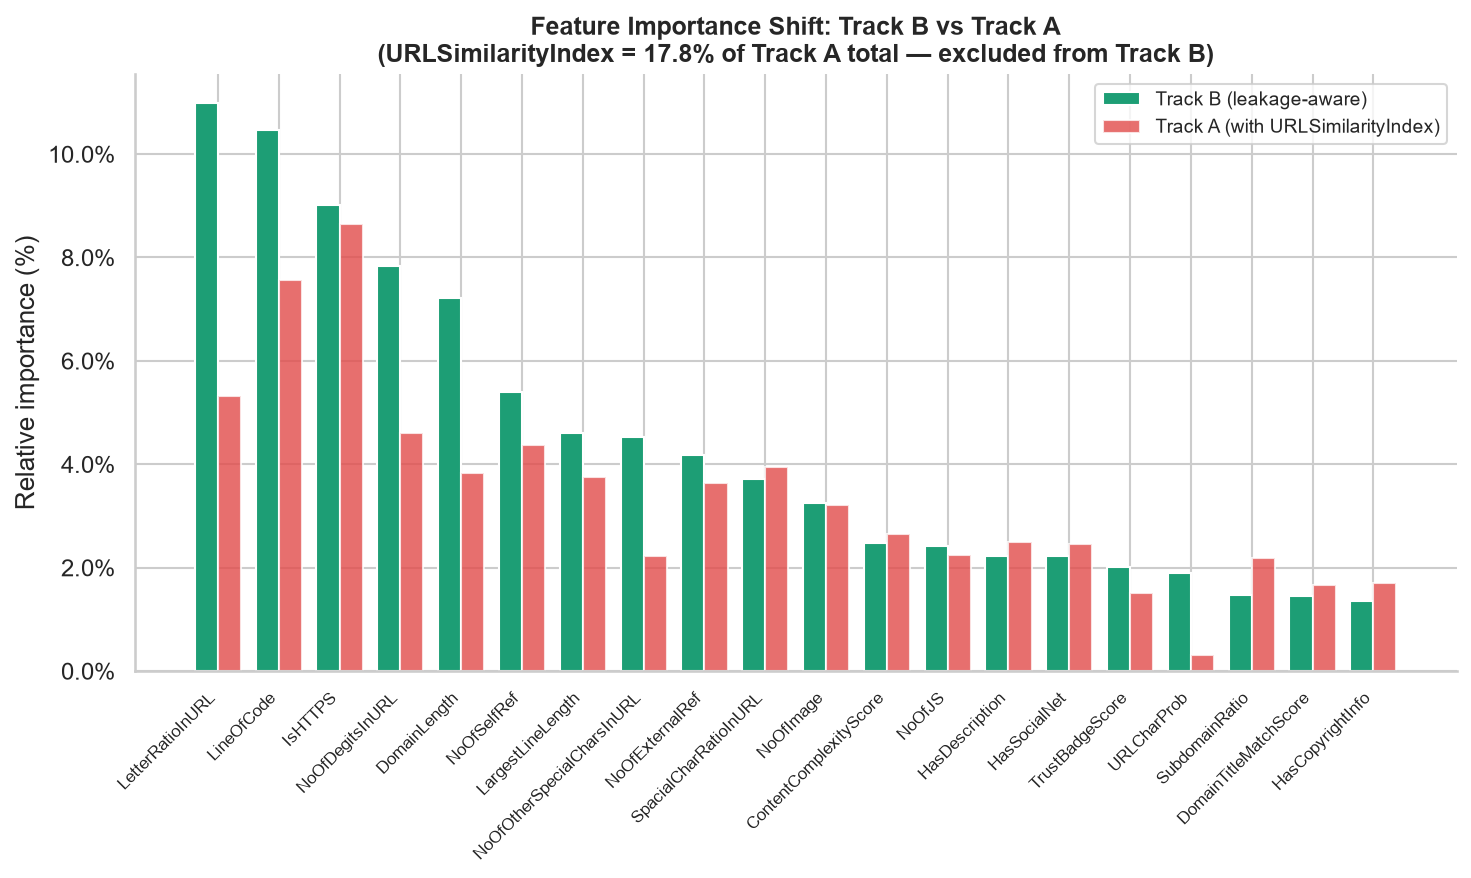

In [20]:
if track_comp.get('comparison_plot_path'):
    display(Image(str(track_comp['comparison_plot_path'])))


## 8. Export SHAP Analysis Report

In [21]:
report_path = generate_shap_report(
    global_r      = global_results,
    local_r       = local_results,
    interaction_r = interaction_results,
    track_comp    = track_comp,
    shap_result   = SHAP_result,
    output_path   = REPORTS_DIR / 'shap_analysis_report.html',
    plots_dir     = PLOTS_SHAP,
)
print(f'SHAP report saved: {report_path}')


2026-06-17 21:00:30 | INFO     | src.explainability.shap_report           | SHAP report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\shap_analysis_report.html


SHAP report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\shap_analysis_report.html


In [22]:
print('Verifying M7.1 artefacts:')
artifacts = [
    'outputs/reports/shap_feature_ranking.csv',
    'outputs/reports/shap_interaction_pairs.csv',
    'outputs/reports/shap_analysis_report.html',
    'outputs/plots/shap/summary_beeswarm.png',
    'outputs/plots/shap/global_importance.png',
    'outputs/plots/shap/interactions/interaction_heatmap.png',
    'outputs/plots/shap/track_comparison_importance.png',
]
import pathlib
for rel in artifacts:
    p = PROJECT_ROOT / rel
    print(f"  {'✓' if p.exists() else '✗'}  {rel}")


Verifying M7.1 artefacts:
  ✓  outputs/reports/shap_feature_ranking.csv
  ✓  outputs/reports/shap_interaction_pairs.csv
  ✓  outputs/reports/shap_analysis_report.html
  ✓  outputs/plots/shap/summary_beeswarm.png
  ✓  outputs/plots/shap/global_importance.png
  ✓  outputs/plots/shap/interactions/interaction_heatmap.png
  ✓  outputs/plots/shap/track_comparison_importance.png


## 9. Downstream Module Interface

In [23]:
print('=' * 65)
print('M7.1 COMPLETE — DOWNSTREAM INTERFACE')
print('=' * 65)
print()
print('A. Top-20 SHAP features object:')
top_20_shap_features = global_results['feature_ranking_df'].head(20)
print(f'   top_20_shap_features: DataFrame {top_20_shap_features.shape}')
print(f'   Top feature: {top_20_shap_features.iloc[0]["feature"]}')
print()
print('B. SHAP values object (for M8.1 LIME, M9, M10):')
print(f'   SHAP_result.shap_values  : np.ndarray {SHAP_result.shap_values.shape}')
print(f'   SHAP_result.feature_names: list of {len(SHAP_result.feature_names)}')
print()
print('C. Interaction values:')
print(f'   interaction_matrix       : np.ndarray {interaction_results["interaction_matrix"].shape}')
print(f'   top_pairs_df             : DataFrame {interaction_results["top_pairs_df"].shape}')
print()
print('D. Selected sample indices (TP/TN/FP/FN):')
for cat, idx in local_results['selected_indices'].items():
    print(f'   {cat.upper()}: {len(idx)} indices = {idx[:3].tolist()}...')
print()
print('E. For M8.1 LIME:')
print(f'   FINAL_DEPLOYMENT_MODEL.predict_proba (callable)')
print(f'   X_train_B.values  : {X_train_B.shape}')
print(f'   X_test_B.values   : {X_test_B.shape}')
print(f'   SHAP_feature_names: list of 56 names')
print(f'   top_20_shap_features: used to focus LIME on key features')
print()
print('F. For M9 Bias Analysis:')
print(f'   SHAP_result.shap_values: SHAP attributions for error sub-groups')
print(f'   global_results["feature_ranking_df"]: top features for group comparison')
print()
print('G. For M10 Blind Spot Analysis:')
print(f'   local_results["selected_indices"]: FP/FN indices for deep-dive')
print(f'   SHAP_result: SHAP attributions for FP/FN sub-group analysis')
print()
print('Next: M8.1 — LIME Explainability')


M7.1 COMPLETE — DOWNSTREAM INTERFACE

A. Top-20 SHAP features object:
   top_20_shap_features: DataFrame (20, 4)
   Top feature: LetterRatioInURL

B. SHAP values object (for M8.1 LIME, M9, M10):
   SHAP_result.shap_values  : np.ndarray (3000, 56)
   SHAP_result.feature_names: list of 56

C. Interaction values:
   interaction_matrix       : np.ndarray (56, 56)
   top_pairs_df             : DataFrame (20, 4)

D. Selected sample indices (TP/TN/FP/FN):
   TP: 10 indices = [229, 2289, 239]...
   TN: 10 indices = [2302, 1199, 1087]...
   FP: 10 indices = [2109, 2284, 836]...
   FN: 10 indices = [2874, 1249, 2216]...

E. For M8.1 LIME:
   FINAL_DEPLOYMENT_MODEL.predict_proba (callable)
   X_train_B.values  : (188296, 56)
   X_test_B.values   : (47074, 56)
   SHAP_feature_names: list of 56 names
   top_20_shap_features: used to focus LIME on key features

F. For M9 Bias Analysis:
   SHAP_result.shap_values: SHAP attributions for error sub-groups
   global_results["feature_ranking_df"]: top fea